In [ ]:
import numpy as np
class DirectLattice2D(object):
    def __init__(self, a1 : np.ndarray, a2: np.ndarray):
        self.a1: np.ndarray = np.array(a1)
        self.a2: np.ndarray = np.array(a2)
        self.A: np.ndarray = np.column_stack((a1,a2))

class ReciprocalLattice2D(object):
    def __init__(self, b1: np.ndarray, b2: np.ndarray):
        self.b1: np.ndarray = np.array(b1)
        self.b2: np.ndarray = np.array(b2)
        self.B: np.ndarray = np.column_stack((b1,b2))

    @staticmethod
    def from_direct_lattice(lattice: DirectLattice2D):
        assert isinstance(lattice, DirectLattice2D)
        B = 2 * np.pi * np.linalg.inv(lattice.A).T
        return ReciprocalLattice2D(b1=B[:,0],b2=B[:,1])

import scipy.sparse as sp
def get_laplacian_1d_direchlet(N, h):
    diag_main =  -2 * np.ones(N)
    diag_off = 1 * np.ones(N-1)
    L = sp.diags(
        [diag_off, diag_main, diag_off],
        [-1,0,1]
    ) / (h**2)
    return L

def get_laplacian_1d_pbc(N, H):
    diag_main = -2 * np.ones(N)
    diag_off = 1 * np.ones(N-1)
    laplacian = sp.diags(
        [diag_off, diag_main, diag_off],
        [-1,0,1]
    )
    laplacian[0,-1] = 1
    laplacian[-1,0] = 1
    return laplacian

def get_1st_derivative_operator(N, h):
    """
    Construct central difference matrix for first derivative d/dx
    with Dirichlet boundary conditions.
    """
    data = [-0.5 * np.ones(N - 1), 0.5 * np.ones(N - 1)]
    offsets = [-1, 1]
    return scipy.sparse.diags(data, offsets) / h

def get_laplacian_2d_uv(
        N, 
        h, 
        G_metric_inv=np.array(
            [[1.,0.],
             [0.,1.]])
        ):
    Ginv_11 = G_metric_inv[0,0]
    Ginv_12 = G_metric_inv[0,1]
    Ginv_22 = G_metric_inv[1,1]

    Du = get_1st_derivative_operator(N,h)
    Dv = get_2nd_derivative_operator(N,h)
    Duu = get_laplacian_1d(N, h)
    Dvv = get_laplacian_2d(N, h)
    Duv = sp.kron(Du, Dv)
    I = sp.eye(N)

    laplacian_uv = Ginv_11 * sp.kron(Duu, I) \
        + Ginv_22 * sp.kron(I, Dvv) \
        + 2*Ginv_12 * Duv

    return laplacian_uv

    



In [ ]:
import numpy as np
import scipy.sparse.linalg as spla
import scipy.sparse as sp

class DirectLattice2D(object):
    def __init__(self, a1 : np.ndarray, a2: np.ndarray):
        self.a1: np.ndarray = np.array(a1)
        self.a2: np.ndarray = np.array(a2)
        self.A: np.ndarray = np.column_stack((a1,a2))

class ReciprocalLattice2D(object):
    def __init__(self, b1: np.ndarray, b2: np.ndarray):
        self.b1: np.ndarray = np.array(b1)
        self.b2: np.ndarray = np.array(b2)
        self.B: np.ndarray = np.column_stack((b1,b2))

    @staticmethod
    def from_direct_lattice(lattice: DirectLattice2D):
        B = 2 * np.pi * np.linalg.inv(lattice.A).T
        return ReciprocalLattice2D(b1=B[:,0],b2=B[:,1])

import scipy.sparse
def get_laplacian_1d(N, h):
    diag_main =  -2 * np.ones(N)
    diag_off = 1 * np.ones(N-1)
    L = sp.diags(
        [diag_off, diag_main, diag_off],
        [-1,0,1]
    ) / (h**2)
    return L

def get_1st_derivative_operator(N, h):
    """
    Construct central difference matrix for first derivative d/dx
    with Dirichlet boundary conditions.
    """
    data = [-0.5 * np.ones(N - 1), 0.5 * np.ones(N - 1)]
    offsets = [-1, 1]
    return sp.diags(data, offsets) / h

def get_laplacian_2d_uv(
        N, 
        h, 
        G_metric_inv=np.array(
            [[1.,0.],
             [0.,1.]])
        ):
    Ginv_11 = G_metric_inv[0,0]
    Ginv_12 = G_metric_inv[0,1]
    Ginv_22 = G_metric_inv[1,1]

    Du = get_1st_derivative_operator(N,h)
    Dv = get_1st_derivative_operator(N,h)
    Duu = get_laplacian_1d(N, h)
    Dvv = get_laplacian_1d(N, h)
    Duv = sp.kron(Du, Dv)
    I = sp.eye(N)

    laplacian_uv = Ginv_11 * sp.kron(Duu, I) \
        + Ginv_22 * sp.kron(I, Dvv) \
        + 2*Ginv_12 * Duv

    return laplacian_uv

class ParticleInABox2D():
    def __init__(self, 
                 lattice: DirectLattice2D,
                 N: int 50,
                 h: float = 1):
        self.hbar = 1.
        self.m = 1.
        self.A_lattice: DirectLattice2D = lattice
        self.B_lattice: ReciprocalLattice2D = \
            ReciprocalLattice2D.from_direct_lattice(lattice=lattice)
        
        # calculate the metric tensor
        self.G_metric = self.A_lattice.A.T @ self.A_lattice.A
        self.G_metric_inv = np.linalg.inv(self.G_metric)
        self.N: int = 50
        self.h: float = 1.
        self.laplacian_uv = self.get_laplacian_uv()
        self.kinetic_operator_uv = self.get_kinetic_operator_uv()
        self.hamiltonian_uv = self.get_hamiltonian_uv()

        self.eigen_N = None
        self.eigen_E_uv = None
        self.eigen_psi_uv = None
        self.eigen_E = None
        self.eigen_psi = None

    def get_laplacian_uv(self):
        self.laplacian_uv = get_laplacian_2d_uv(
            N = self.N,
            h = self.h,
            G_metric_inv = self.G_metric_inv
        )
        return self.laplacian_uv

    def get_kinetic_operator_uv(self):
        hbar = self.hbar
        m = self.m
        L_uv = self.laplacian_uv
        KEhat_uv = -(hbar**2) / (2*m) * L_uv
        return KEhat_uv

    def get_hamiltonian_uv(self):
        Hhat_uv = self.kinetic_operator_uv
        return Hhat_uv
        
    def solve_uv(self, eigen_N=20):
        assert isinstance(eigen_N, int)
        assert eigen_N > 0
        self.eigen_N = eigen_N

        self.eigen_E_uv, self.eigen_psi_uv = \
            spla.eigsh(
                self.hamiltonian_uv,
                k=eigen_N,
                which='SM'
            )

    def solve_xy(self, eigen_N=20):
        self.solve_uv(eigen_N=eigen_N)

        u = np.linspace(0,1,self.N)
        v = np.linspace(0,1,self.N)
        U,V = np.meshgrid(u,v, indexing="ij")

        UV = np.stack([U.ravel(), V.ravel()], axis=0)
        XY = self.A_lattice.A @ UV

        self.x = XY[0].reshape((self.N,self.N))
        self.y = XY[1].reshape((self.N,self.N))

        self.eigen_E = self.eigen_E_uv
        self.eigen_psi = [
            self.eigen_psi_uv[:,i].reshape((self.N,self.N))
            for i in range(eigen_N)
        ]
        return self.x, self.y


In [43]:
import numpy as np

hbar = 1.
m = 1.

a1: np.ndarray = np.array([1.0, 0.0])
a2: np.ndarray = np.array([0.0, 1.])
A: np.ndarray = np.column_stack((a1, a2))

G = A.T @ A
Ginv = np.linalg.inv(G)
print("G = \n",G)
print("Ginv = \n", Ginv)


G = 
 [[1. 0.]
 [0. 1.]]
Ginv = 
 [[1. 0.]
 [0. 1.]]


In [44]:
# Usage example:
a1 = np.array([1.0, 0.0])
a2 = np.array([0.5, 1.0])
lattice = DirectLattice2D(a1, a2)
particle = ParticleInABox2D(lattice)
x, y = particle.solve_xy(eigen_N=5)
print(particle.eigen_E)

[0.00408986 0.00866224 0.01175477 0.01408338 0.01944133]


In [46]:
import matplotlib.pyplot as plt
def plot_probability_density(x, y, psi, E=None, index=None, cmap='viridis'):
    """
    Visualize the probability density |ψ(x,y)|² on the real-space grid.
    
    Parameters:
    - x, y: (N, N) arrays of real-space coordinates
    - psi: (N, N) array, the wavefunction ψ(x, y)
    - E: optional, energy value to display
    - index: optional, eigenstate index
    - cmap: colormap
    """
    prob_density = np.abs(psi)**2

    plt.figure(figsize=(5, 4))
    plt.pcolormesh(x, y, prob_density, shading='auto', cmap=cmap)
    plt.gca().set_aspect('equal')
    title = ""
    if index is not None:
        title += f"ψ[{index}] "
    if E is not None:
        title += f"E = {E:.4f}"
    plt.title(title)
    plt.colorbar(label=r"$|\psi(x,y)|^2$")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

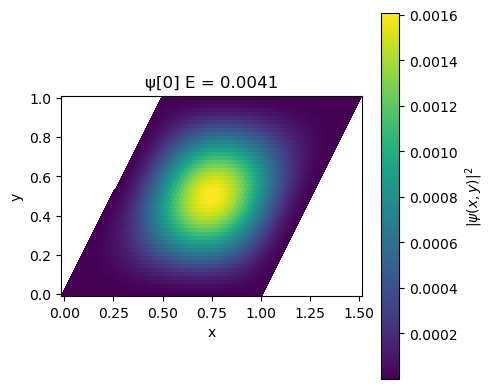

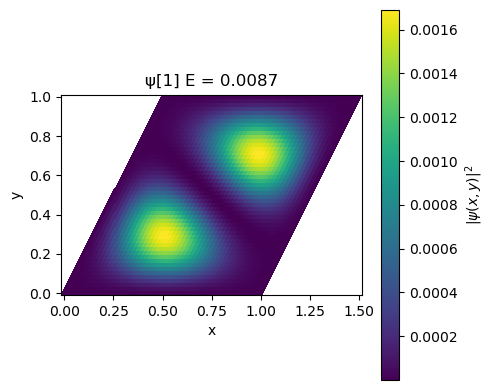

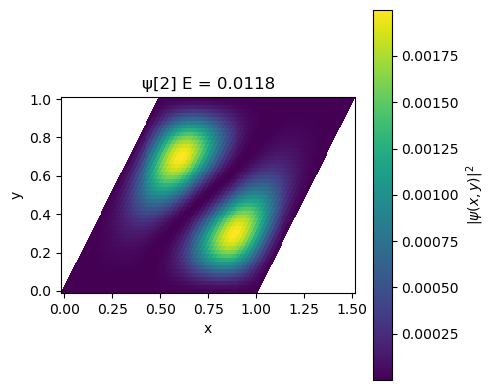

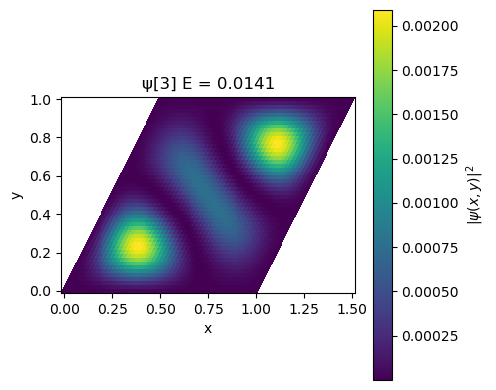

In [47]:
for i in range(4):
    plot_probability_density(
        particle.x, 
        particle.y, 
        particle.eigen_psi[i], 
        E=particle.eigen_E[i], index=i)